**Assignment 4:-** Use Naïve Bayes or TF-IDF + SVM to classify emails as phishing or legitimate based on word patterns.

**Student Name:-** Tejasvini Fulari

**Roll NO.:-** EN24107039
    
**Class:-** TY AIDS-A

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay
)
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [114]:
df = pd.read_csv("CEAS_08.csv")
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [115]:
df.columns

Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='object')

In [116]:
df.shape

(39154, 7)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [118]:
df.describe()

,label,urls
count,39154.000000,39154.00000
mean,0.557848,0.66997
std,0.496649,0.47023
min,0.000000,0.00000
25%,0.000000,0.00000
50%,1.000000,1.00000
75%,1.000000,1.00000
max,1.000000,1.00000


In [119]:
df.isnull().sum()

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

In [120]:
df["subject"] = df["subject"].fillna("")

In [121]:
df["receiver"] = df["receiver"].fillna("")

In [122]:
df.isnull().sum()

sender      0
receiver    0
date        0
subject     0
body        0
label       0
urls        0
dtype: int64

In [123]:
df["label"].value_counts()

label
1    21842
0    17312
Name: count, dtype: int64

In [124]:
df["label"].value_counts(normalize=True) * 100

label
1    55.78485
0    44.21515
Name: proportion, dtype: float64

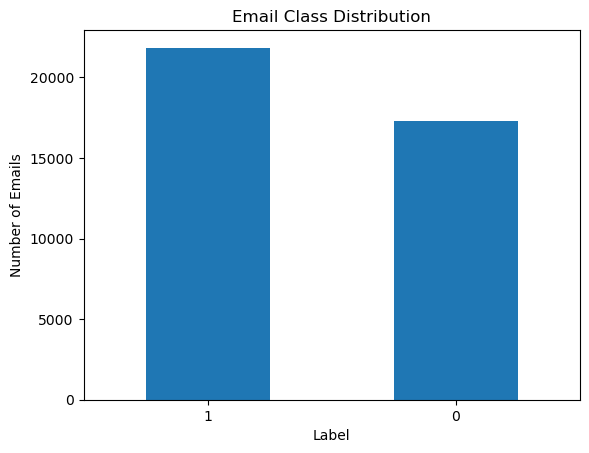

In [125]:
import matplotlib.pyplot as plt
df["label"].value_counts().plot(kind="bar")
plt.title("Email Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()

In [126]:
df["email_text"] = df["subject"] + " " + df["body"]

In [127]:
print(df["email_text"].iloc[0])

Never agree to be a loser Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same.


In [128]:
X = df["email_text"]
y = df["label"]

In [129]:
X.head()
y.head()

0    1
1    1
2    1
3    0
4    1
Name: label, dtype: int64

In [130]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,
test_size=0.20,
random_state=42,
stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 31323
Testing samples: 7831


In [131]:
vectorizer = TfidfVectorizer(

lowercase=True,
stop_words="english",
max_features=10000,
ngram_range=(1, 2)
)

In [132]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [133]:
X_test_tfidf = vectorizer.transform(X_test)

In [134]:
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (31323, 10000)
Testing TF-IDF Shape: (7831, 10000)


In [135]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [136]:
y_pred = model.predict(X_test_tfidf)

In [137]:
print("Actual labels:")
print(y_test.head(10).values)
print("\nPredicted labels:")
print(y_pred[:10])

Actual labels:
[1 0 0 1 1 1 1 1 0 0]

Predicted labels:
[1 0 0 1 1 1 1 1 0 0]


In [138]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9791852892350913
Accuracy Percentage: 97.91852892350913 %


In [139]:
precision = precision_score(

y_test,
y_pred,
average="weighted"
)
recall = recall_score(
y_test,
y_pred,
average="weighted"
)
f1 = f1_score(
y_test,
y_pred,
average="weighted"
)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9799170845724573
Recall: 0.9791852892350913
F1 Score: 0.9792227277664736


In [140]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3462
           1       1.00      0.96      0.98      4369

    accuracy                           0.98      7831
   macro avg       0.98      0.98      0.98      7831
weighted avg       0.98      0.98      0.98      7831



In [141]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3452   10]
 [ 153 4216]]


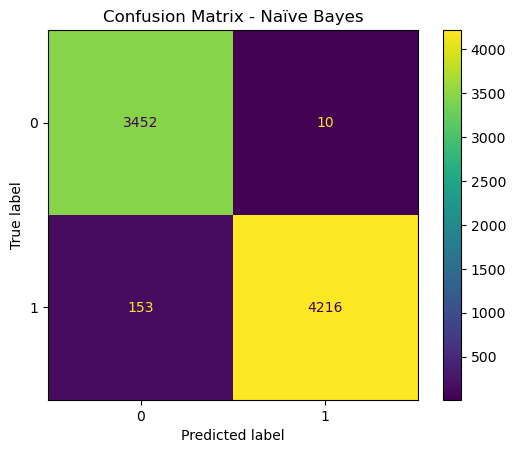

In [142]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)
disp.plot()
plt.title("Confusion Matrix - Naïve Bayes")
plt.show()

In [143]:
new_email = [
"""
Dear Customer,
Your bank account has been suspended.
Please click the link below immediately to verify
your account and confirm your password.
"""
]

In [144]:
new_email_tfidf = vectorizer.transform(new_email)

In [145]:
prediction = model.predict(new_email_tfidf)
print("Prediction:", prediction)

Prediction: [0]


In [146]:
if prediction[0] == 1:
    print("Result: PHISHING / SPAM EMAIL")
else:
    print("Result: LEGITIMATE EMAIL")

Result: LEGITIMATE EMAIL


In [147]:
probability = model.predict_proba(new_email_tfidf)
print(probability)

[[0.60206388 0.39793612]]


In [148]:
print("Probability of Class 0:", probability[0][0])
print("Probability of Class 1:", probability[0][1])

Probability of Class 0: 0.6020638773474329
Probability of Class 1: 0.39793612265256845


**Linear SVM**

In [149]:
from sklearn.svm import LinearSVC
model = LinearSVC()

In [150]:
model = LinearSVC()
model.fit(X_train_tfidf, y_train)

LinearSVC()

In [151]:
y_pred = model.predict(X_test_tfidf)

print("Actual labels:")
print(y_test.head(10).values)

print("\nPredicted labels:")
print(y_pred[:10])

Actual labels:
[1 0 0 1 1 1 1 1 0 0]

Predicted labels:
[1 0 0 1 1 1 1 1 0 0]


In [152]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9969352573106883
Accuracy Percentage: 99.69352573106883 %


In [153]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9969352049436957
Recall: 0.9969352573106883
F1 Score: 0.9969351652138186


In [154]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3462
           1       1.00      1.00      1.00      4369

    accuracy                           1.00      7831
   macro avg       1.00      1.00      1.00      7831
weighted avg       1.00      1.00      1.00      7831



In [155]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3449   13]
 [  11 4358]]


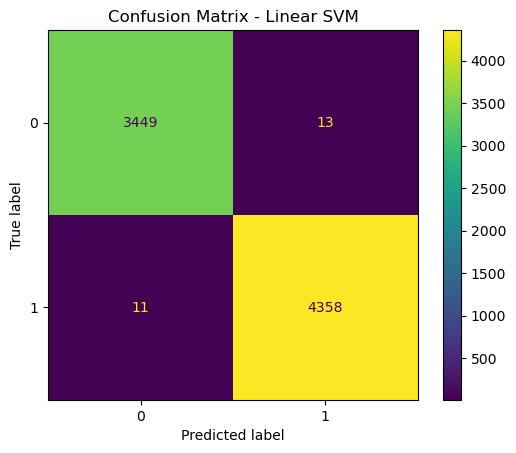

In [156]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [157]:
new_email = [
    """decision_score = model.decision_function(new_email_tfidf)

print("Decision Score:", decision_score)
    Dear Customer,
    Your bank account has been suspended.
    Please click the link below immediately to verify
    your account and confirm your password.
    """
]

In [158]:
new_email_tfidf = vectorizer.transform(new_email)

In [159]:
prediction = model.predict(new_email_tfidf)

print("Prediction:", prediction)

Prediction: [0]


In [160]:
if prediction[0] == 1:
    print("Result: PHISHING / SPAM EMAIL")
else:
    print("Result: LEGITIMATE EMAIL")

Result: LEGITIMATE EMAIL
